In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
import os
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
DATASET_PATH = Path("../data/train_dataset_for_students")

IMG_PATH = DATASET_PATH / "img"
LABEL_PATH = DATASET_PATH / "labels"

splits = ["train","val","test"]

In [3]:
missing_masks = []
missing_images = []
matched = []

for split in splits:
    
    img_dir = IMG_PATH / split
    mask_dir = LABEL_PATH / split
    
    img_files = {f.stem: f for f in img_dir.glob("*.jpg")}
    mask_files = {f.stem: f for f in mask_dir.glob("*.png")}
    
    for name in img_files:
        if name not in mask_files:
            missing_masks.append((split, name))
        else:
            matched.append((split, name))
    
    for name in mask_files:
        if name not in img_files:
            missing_images.append((split, name))

print("Всего корректных пар:", len(matched))
print("Картинок без масок:", len(missing_masks))
print("Масок без картинок:", len(missing_images))

Всего корректных пар: 440
Картинок без масок: 0
Масок без картинок: 0


In [4]:
from pathlib import Path

# Пути к папкам
IMG_PATH = Path('../data/train_dataset_for_students/img')
LABEL_PATH = Path('../data/train_dataset_for_students/labels')

splits = ["train", "val", "test"]

# Создаем словари для результатов
results = {}

for split in splits:
    img_dir = IMG_PATH / split
    mask_dir = LABEL_PATH / split
    
    # Берем все файлы и игнорируем регистр расширения
    img_files = {f.stem: f for f in img_dir.glob("*") if f.suffix.lower() in [".jpg", ".jpeg", ".png"]}
    mask_files = {f.stem: f for f in mask_dir.glob("*") if f.suffix.lower() == ".png"}
    
    matched = []
    missing_masks = []
    missing_images = []
    
    # Проверяем наличие масок для каждой картинки
    for name in img_files:
        if name not in mask_files:
            missing_masks.append(name)
        else:
            matched.append(name)
    
    # Проверяем наличие картинок для каждой маски
    for name in mask_files:
        if name not in img_files:
            missing_images.append(name)
    
    # Сохраняем статистику по этому split
    results[split] = {
        "matched": matched,
        "missing_masks": missing_masks,
        "missing_images": missing_images
    }

# Выводим статистику
for split in splits:
    print(f"=== {split.upper()} ===")
    print("Всего корректных пар:", len(results[split]["matched"]))
    print("Картинок без масок:", len(results[split]["missing_masks"]))
    print("Масок без картинок:", len(results[split]["missing_images"]))
    print()


=== TRAIN ===
Всего корректных пар: 200
Картинок без масок: 0
Масок без картинок: 0

=== VAL ===
Всего корректных пар: 120
Картинок без масок: 0
Масок без картинок: 0

=== TEST ===
Всего корректных пар: 120
Картинок без масок: 0
Масок без картинок: 0



In [5]:
COLORS = {
    0: [0, 0, 0],        # background
    1: [255, 0, 0],      # cat (красный)
    2: [0, 255, 0]       # dog (зеленый)
}

Блок 2 — собрать пары изображение-маска

In [6]:
matched = []

for split in splits:

    img_dir = IMG_PATH / split
    mask_dir = LABEL_PATH / split

    img_files = {f.stem for f in img_dir.glob("*.jpg")}
    mask_files = {f.stem for f in mask_dir.glob("*.png")}

    common = img_files.intersection(mask_files)

    for name in common:
        matched.append((split,name))

print("Найдено пар image-mask:", len(matched))

Найдено пар image-mask: 440


In [7]:
def overlay_mask(image, mask, alpha=0.5):
    overlay = image.copy()
    # Список цветов для каждого класса (класс 0 — фон)
    colors = {
        1: [255, 0, 0],    # класс 1 — красный
        2: [0, 255, 0],    # класс 2 — зеленый
        3: [0, 0, 255],    # класс 3 — синий
        # добавь остальные классы по необходимости
    }
    
    for cls, color in colors.items():
        overlay[mask == cls] = (overlay[mask == cls] * (1 - alpha) + np.array(color) * alpha).astype(np.uint8)
    
    return overlay

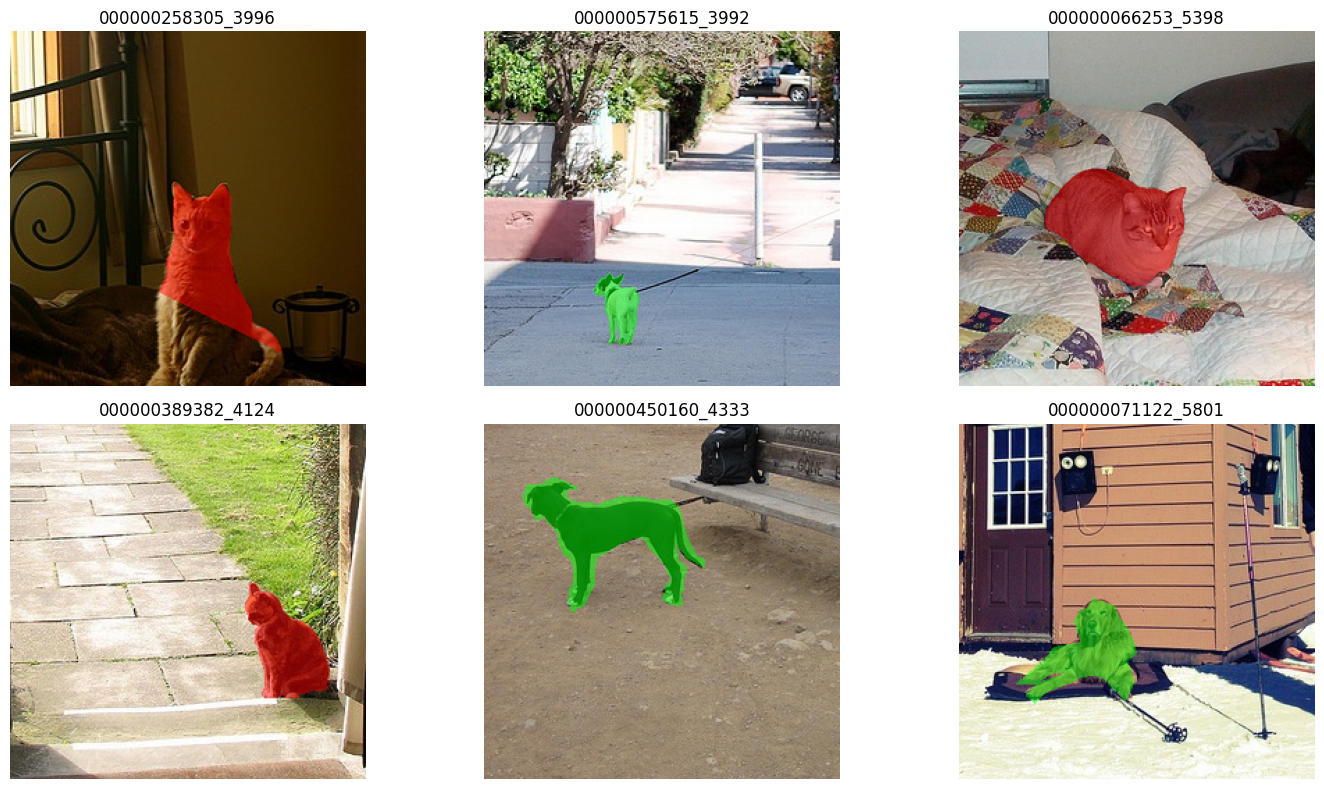

In [8]:
samples = random.sample(matched, 6)

plt.figure(figsize=(15,8))

for i,(split,name) in enumerate(samples):

    img_path = IMG_PATH / split / f"{name}.jpg"
    mask_path = LABEL_PATH / split / f"{name}.png"

    img = np.array(Image.open(img_path))
    mask = np.array(Image.open(mask_path))

    overlay = overlay_mask(img, mask)

    plt.subplot(2,3,i+1)
    plt.imshow(overlay)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

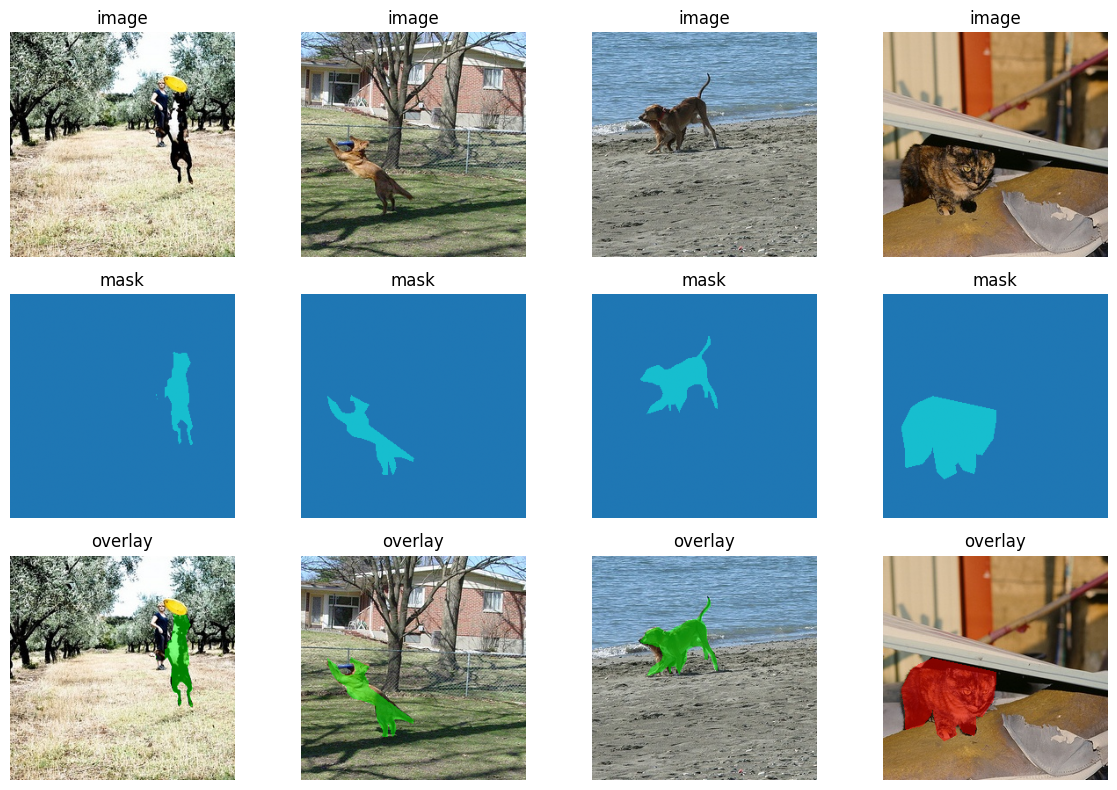

In [9]:
samples = random.sample(matched, 4)

plt.figure(figsize=(12,8))

for i,(split,name) in enumerate(samples):

    img_path = IMG_PATH / split / f"{name}.jpg"
    mask_path = LABEL_PATH / split / f"{name}.png"

    img = np.array(Image.open(img_path))
    mask = np.array(Image.open(mask_path))

    overlay = overlay_mask(img, mask)

    plt.subplot(3,4,i+1)
    plt.imshow(img)
    plt.title("image")
    plt.axis("off")

    plt.subplot(3,4,i+5)
    plt.imshow(mask, cmap="tab10")
    plt.title("mask")
    plt.axis("off")

    plt.subplot(3,4,i+9)
    plt.imshow(overlay)
    plt.title("overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()

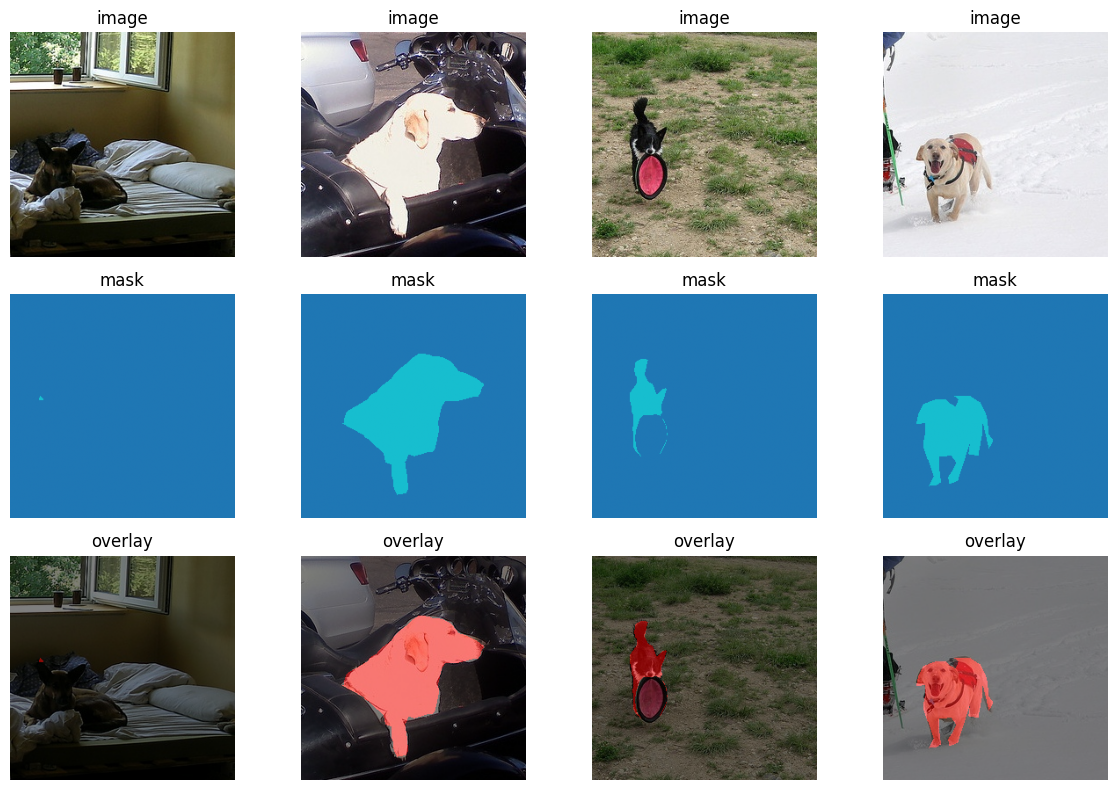

In [10]:
import random
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Пути к данным
IMG_PATH = Path('../data/train_dataset_for_students/img/train')
LABEL_PATH = Path('../data/train_dataset_for_students/labels/train')

# Пример matched: список кортежей (split, name)
matched = [
    ("train", "000000016206_4014"),
    ("train", "000000026730_391"),
    ("train", "000000028253_7169"),
    ("train", "000000030752_6513"),
    ("train", "000000040466_5639"),
    ("train", "000000045040_1484"),
    ("train", "000000045587_1711"),
]

# Функция для создания оверлея
def overlay_mask(image, mask, alpha=0.5):
    """Накладывает маску на изображение с прозрачностью alpha"""
    color_mask = np.zeros_like(image)
    # Задаем цвет для каждого класса (например, класс 2 — красный)
    color_mask[mask == 2] = [255, 0, 0]
    overlay = image.copy()
    overlay = (overlay * (1 - alpha) + color_mask * alpha).astype(np.uint8)
    return overlay

# Берем случайные 4 примера
samples = random.sample(matched, 4)

plt.figure(figsize=(12, 8))

for i, (split, name) in enumerate(samples):
    img_path = IMG_PATH / f"{name}.jpg"
    mask_path = LABEL_PATH / f"{name}.png"

    img = np.array(Image.open(img_path))
    mask = np.array(Image.open(mask_path))

    overlay = overlay_mask(img, mask)

    # Изображение
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title("image")
    plt.axis("off")

    # Маска
    plt.subplot(3, 4, i + 5)
    plt.imshow(mask, cmap="tab10")
    plt.title("mask")
    plt.axis("off")

    # Оверлей
    plt.subplot(3, 4, i + 9)
    plt.imshow(overlay)
    plt.title("overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()

Всего корректных пар в train: 200


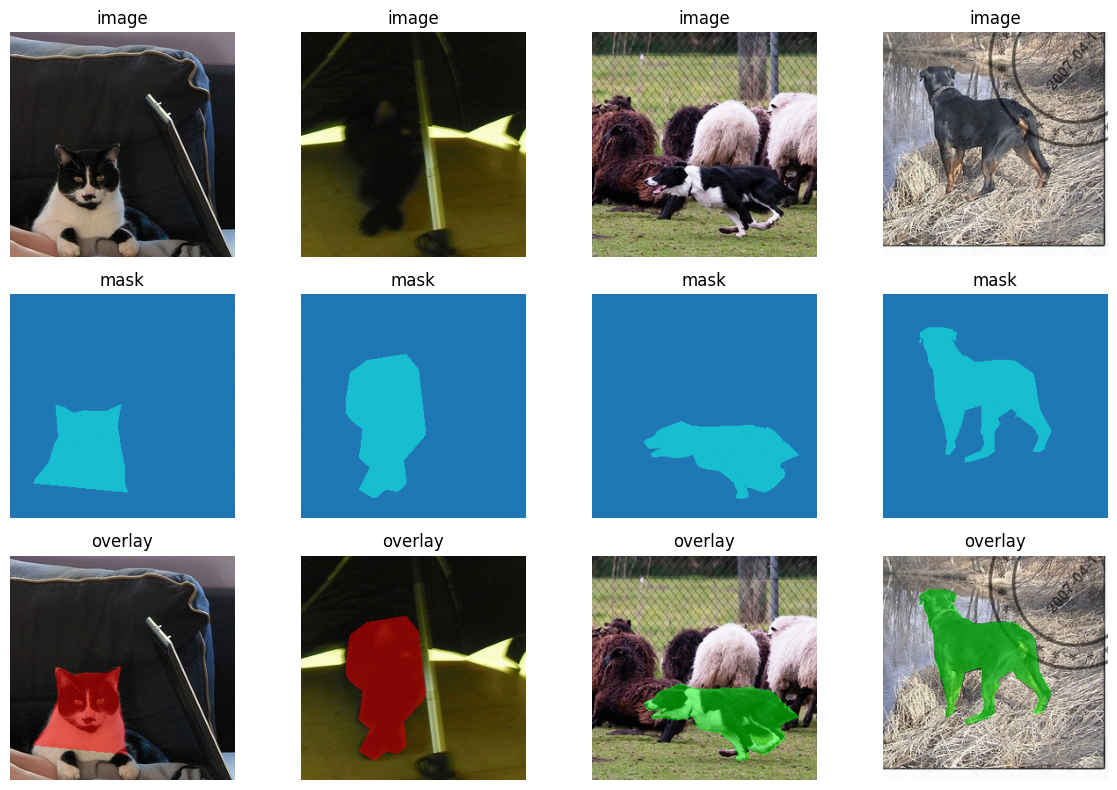

In [11]:
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

# Пути к данным
IMG_PATH = Path('../data/train_dataset_for_students/img')
LABEL_PATH = Path('../data/train_dataset_for_students/labels')
split = "train"

# Получаем все картинки и маски train
img_dir = IMG_PATH / split
mask_dir = LABEL_PATH / split

img_files = {f.stem: f for f in img_dir.glob("*") if f.suffix.lower() in [".jpg", ".jpeg", ".png"]}
mask_files = {f.stem: f for f in mask_dir.glob("*") if f.suffix.lower() == ".png"}

# Формируем только корректные пары
matched = [name for name in img_files if name in mask_files]
print(f"Всего корректных пар в train: {len(matched)}")

def overlay_mask(image, mask, alpha=0.5):
    overlay = image.copy()
    # Список цветов для каждого класса (класс 0 — фон)
    colors = {
        1: [255, 0, 0],    # класс 1 — красный
        2: [0, 255, 0],    # класс 2 — зеленый
        3: [0, 0, 255],    # класс 3 — синий
        # добавь остальные классы по необходимости
    }
    
    for cls, color in colors.items():
        overlay[mask == cls] = (overlay[mask == cls] * (1 - alpha) + np.array(color) * alpha).astype(np.uint8)
    
    return overlay
# Выбираем случайные 4 примера
samples = random.sample(matched, min(4, len(matched)))

plt.figure(figsize=(12, 8))

for i, name in enumerate(samples):
    img_path = img_dir / f"{name}.jpg"
    mask_path = mask_dir / f"{name}.png"

    img = np.array(Image.open(img_path))
    mask = np.array(Image.open(mask_path))
    overlay = overlay_mask(img, mask)

    # Изображение
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title("image")
    plt.axis("off")

    # Маска
    plt.subplot(3, 4, i + 5)
    plt.imshow(mask, cmap="tab10")
    plt.title("mask")
    plt.axis("off")

    # Оверлей
    plt.subplot(3, 4, i + 9)
    plt.imshow(overlay)
    plt.title("overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
!pip install scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 30.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-image] [scikit-image]


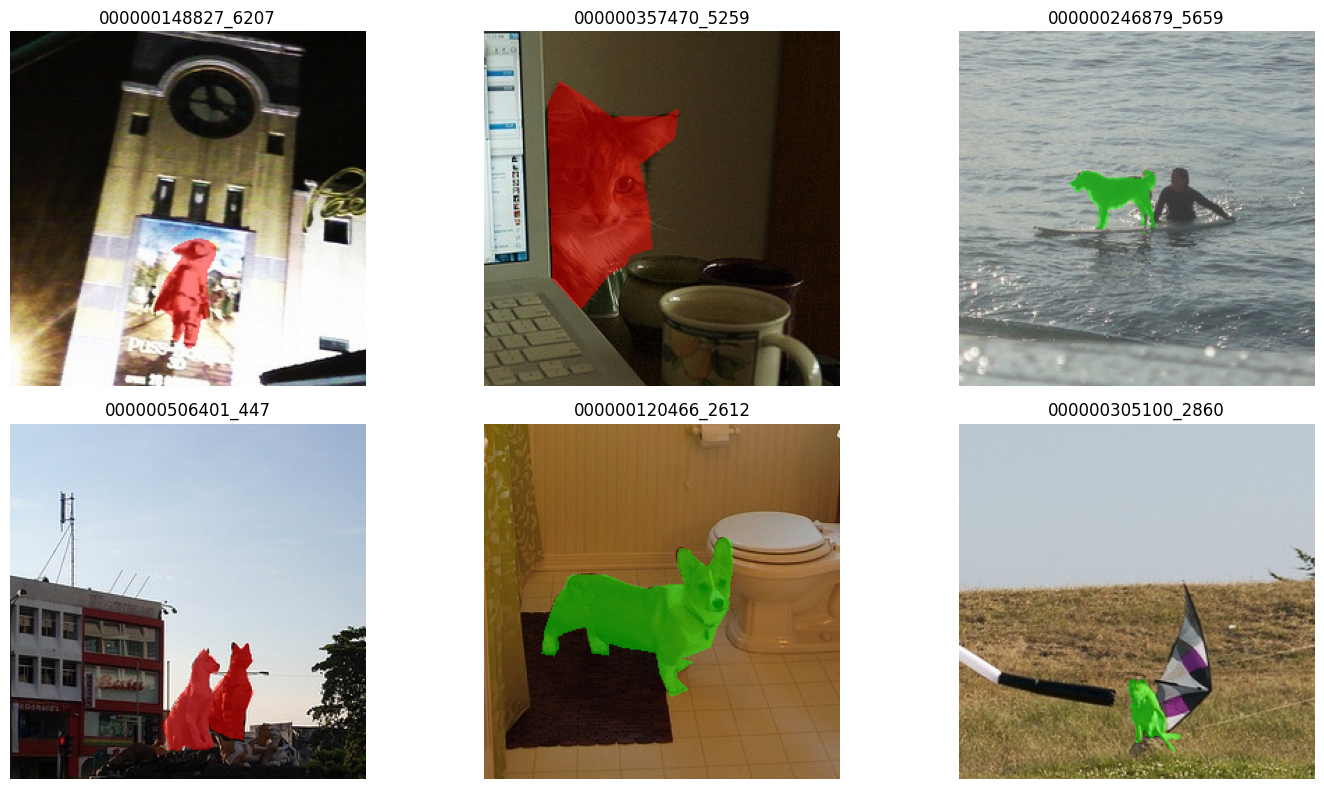

In [25]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import random

# Пути к данным
IMG_PATH = Path("../data/train_dataset_for_students/img/train")
LABEL_PATH = Path("../data/train_dataset_for_students/labels/train")

# Собираем пары
img_files = {f.stem: f for f in IMG_PATH.glob("*") if f.suffix.lower() in [".jpg", ".jpeg", ".png"]}
mask_files = {f.stem: f for f in LABEL_PATH.glob("*") if f.suffix.lower() == ".png"}
matched = [name for name in img_files if name in mask_files]

# Функция оверлея (твой существующий)
def overlay_mask(image, mask, alpha=0.5):
    overlay = image.copy()
    colors = {
        1: [255, 0, 0],    # класс 1 — красный
        2: [0, 255, 0],    # класс 2 — зеленый
        3: [0, 0, 255],    # класс 3 — синий
    }
    for cls, color in colors.items():
        overlay[mask == cls] = (overlay[mask == cls]*(1-alpha) + np.array(color)*alpha).astype(np.uint8)
    return overlay

# Постраничный вывод
batch_size = 6
num_pages = (len(matched) + batch_size - 1) // batch_size

for page in range(num_pages)[:1]:
    batch = matched[page*batch_size : (page+1)*batch_size]
    plt.figure(figsize=(15, 8))
    
    for i, name in enumerate(batch):
        img_path = IMG_PATH / f"{name}.jpg"
        mask_path = LABEL_PATH / f"{name}.png"

        img = np.array(Image.open(img_path))
        mask = np.array(Image.open(mask_path))

        overlay = overlay_mask(img, mask)

        plt.subplot(2, 3, i+1)
        plt.imshow(overlay)
        plt.title(name)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

In [26]:
# import numpy as np
# from PIL import Image
# import matplotlib.pyplot as plt
# from pathlib import Path
# import random

# # Пути к данным
# IMG_PATH = Path("../data/train_dataset_for_students/img/val")
# LABEL_PATH = Path("../data/train_dataset_for_students/labels/val")

# # Собираем пары
# img_files = {f.stem: f for f in IMG_PATH.glob("*") if f.suffix.lower() in [".jpg", ".jpeg", ".png"]}
# mask_files = {f.stem: f for f in LABEL_PATH.glob("*") if f.suffix.lower() == ".png"}
# matched = [name for name in img_files if name in mask_files]

# # Функция оверлея (твой существующий)
# def overlay_mask(image, mask, alpha=0.5):
#     overlay = image.copy()
#     colors = {
#         1: [255, 0, 0],    # класс 1 — красный
#         2: [0, 255, 0],    # класс 2 — зеленый
#         3: [0, 0, 255],    # класс 3 — синий
#     }
#     for cls, color in colors.items():
#         overlay[mask == cls] = (overlay[mask == cls]*(1-alpha) + np.array(color)*alpha).astype(np.uint8)
#     return overlay

# # Постраничный вывод
# batch_size = 6
# num_pages = (len(matched) + batch_size - 1) // batch_size

# for page in range(num_pages):
#     batch = matched[page*batch_size : (page+1)*batch_size]
#     plt.figure(figsize=(15, 8))
    
#     for i, name in enumerate(batch):
#         img_path = IMG_PATH / f"{name}.jpg"
#         mask_path = LABEL_PATH / f"{name}.png"

#         img = np.array(Image.open(img_path))
#         mask = np.array(Image.open(mask_path))

#         overlay = overlay_mask(img, mask)

#         plt.subplot(2, 3, i+1)
#         plt.imshow(overlay)
#         plt.title(name)
#         plt.axis("off")
    
#     plt.tight_layout()
#     plt.show()

In [27]:
# import numpy as np
# from PIL import Image
# import matplotlib.pyplot as plt
# from pathlib import Path
# import random

# # Пути к данным
# IMG_PATH = Path("../data/train_dataset_for_students/img/test")
# LABEL_PATH = Path("../data/train_dataset_for_students/labels/test")

# # Собираем пары
# img_files = {f.stem: f for f in IMG_PATH.glob("*") if f.suffix.lower() in [".jpg", ".jpeg", ".png"]}
# mask_files = {f.stem: f for f in LABEL_PATH.glob("*") if f.suffix.lower() == ".png"}
# matched = [name for name in img_files if name in mask_files]

# # Функция оверлея (твой существующий)
# def overlay_mask(image, mask, alpha=0.5):
#     overlay = image.copy()
#     colors = {
#         1: [255, 0, 0],    # класс 1 — красный
#         2: [0, 255, 0],    # класс 2 — зеленый
#         3: [0, 0, 255],    # класс 3 — синий
#     }
#     for cls, color in colors.items():
#         overlay[mask == cls] = (overlay[mask == cls]*(1-alpha) + np.array(color)*alpha).astype(np.uint8)
#     return overlay

# # Постраничный вывод
# batch_size = 6
# num_pages = (len(matched) + batch_size - 1) // batch_size

# for page in range(num_pages):
#     batch = matched[page*batch_size : (page+1)*batch_size]
#     plt.figure(figsize=(15, 8))
    
#     for i, name in enumerate(batch):
#         img_path = IMG_PATH / f"{name}.jpg"
#         mask_path = LABEL_PATH / f"{name}.png"

#         img = np.array(Image.open(img_path))
#         mask = np.array(Image.open(mask_path))

#         overlay = overlay_mask(img, mask)

#         plt.subplot(2, 3, i+1)
#         plt.imshow(overlay)
#         plt.title(name)
#         plt.axis("off")
    
#     plt.tight_layout()
#     plt.show()

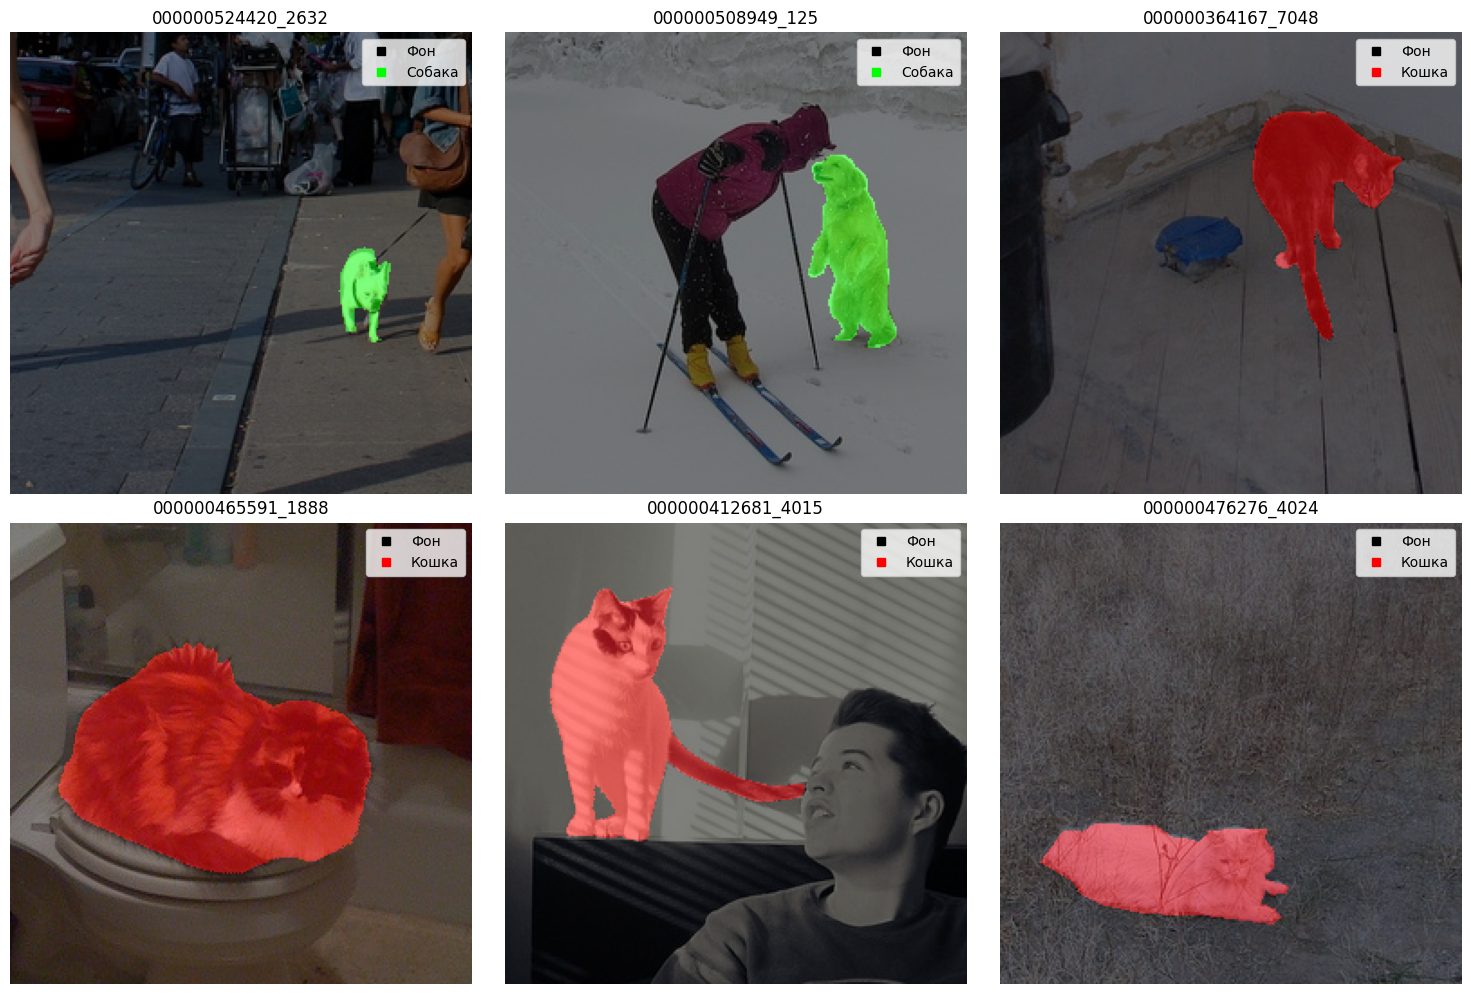

In [28]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import math

# Пути к данным
IMG_PATH = Path("../data/train_dataset_for_students/img/test")
LABEL_PATH = Path("../data/train_dataset_for_students/labels/test")

# Собираем файлы
img_files = {f.stem: f for f in IMG_PATH.glob("*") if f.suffix.lower() in [".jpg", ".jpeg", ".png"]}
mask_files = {f.stem: f for f in LABEL_PATH.glob("*") if f.suffix.lower() == ".png"}
matched = [name for name in img_files if name in mask_files]

# Настройки классов (ключи должны соответствовать значениям в масках)
class_names = {
    0: "Фон",
    1: "Кошка",
    2: "Собака"
}

colors = {
    0: [0, 0, 0],       # фон — черный
    1: [255, 0, 0],     # красная кошка
    2: [0, 255, 0]      # зеленая собака
}

# Функция наложения маски
def overlay_mask(image, mask, alpha=0.5):
    overlay = image.copy()
    for cls, color in colors.items():
        overlay[mask == cls] = (overlay[mask == cls]*(1-alpha) + np.array(color)*alpha).astype(np.uint8)
    return overlay

# Параметры отображения
batch_size = 6
cols = 3  # количество колонок в subplot
rows = math.ceil(batch_size / cols)
num_pages = (len(matched) + batch_size - 1) // batch_size

# Постраничный вывод
for page in range(num_pages)[:1]:
    batch = matched[page*batch_size : (page+1)*batch_size]
    plt.figure(figsize=(5*cols, 5*rows))
    
    for i, name in enumerate(batch):
        img_path = IMG_PATH / f"{name}.jpg"
        mask_path = LABEL_PATH / f"{name}.png"

        img = np.array(Image.open(img_path))
        mask = np.array(Image.open(mask_path))

        overlay = overlay_mask(img, mask)

        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(overlay)
        ax.set_title(name)
        ax.axis("off")
        
        # Легенда для классов, которые реально есть на маске
        unique_classes = np.unique(mask)
        patches = [plt.plot([], [], marker="s", ls="", color=np.array(colors[cls])/255, 
                            label=class_names.get(cls, f"Class {cls}"))[0] 
                   for cls in unique_classes]
        ax.legend(handles=patches, loc="upper right", fontsize=10)

    plt.tight_layout()
    plt.show()

In [23]:
from PIL import Image
import numpy as np
from pathlib import Path

# Путь к папке с масками
LABEL_PATH = Path("../data/train_dataset_for_students/labels/train")

# Список всех PNG-файлов в папке
mask_files = list(LABEL_PATH.glob("*.png"))

for mask_path in mask_files:
    mask = np.array(Image.open(mask_path))
    unique_values = np.unique(mask)
    print(f"{mask_path.name}: {unique_values}")

000000046230_7013.png: [0 2]
000000097902_3578.png: [0 2]
000000512068_4624.png: [0 1]
000000481101_7500.png: [0 2]
000000067445_4881.png: [0 2]
000000435698_3318.png: [0 1]
000000275919_4499.png: [0 1]
000000576855_2826.png: [0 2]
000000509018_7223.png: [0 1]
000000476468_3727.png: [0 2]
000000287341_6222.png: [0 2]
000000400134_3371.png: [0 2]
000000478351_2868.png: [0 2]
000000077325_4727.png: [0 2]
000000180672_4127.png: [0 1]
000000285699_2690.png: [0 1]
000000149184_281.png: [0 1]
000000177413_4194.png: [0 1]
000000031865_4082.png: [0 1]
000000536400_813.png: [0 2]
000000317781_4461.png: [0 2]
000000040466_5639.png: [0 2]
000000208910_3663.png: [0 2]
000000116503_5471.png: [0 1]
000000070815_324.png: [0 2]
000000171753_498.png: [0 1]
000000390262_3700.png: [0 2]
000000045587_1711.png: [0 2]
000000120466_2612.png: [0 2]
000000138186_7149.png: [0 1]
000000419618_7033.png: [0 1]
000000474434_3544.png: [0 1]
000000323466_5790.png: [0 2]
000000506401_447.png: [0 1]
000000071313_4743.p

 Предварительный анализ датасета показал что всего 2 класса. Ошибок в названиях нет
 Есть маски которые плохо размечены, то есть они не покрывают полностью часть картинки с классом - но тем не менее цветовая разметка верная, поэтому пока ничего доразмечать и удалять не будут, тем более таких картииног не более 5%.

 Чтобы отрисовать весь датасет методами mssegmentation через файл test_visualizer - нужно сначала зарегистрировать датасет с его 3 классами - фон/ собака и кошка, что сделаю в следующем этапе